In [1]:
import os
import re
import json
import torch
import pandas as pd
import torch.nn.functional as F

from PIL import Image
from transformers import (
    TrOCRProcessor,
    VisionEncoderDecoderModel,
    AutoTokenizer,
    AutoModelForSequenceClassification
)

In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


In [3]:
print("Loading TrOCR...")
trocr_processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
trocr_model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-handwritten")
trocr_model.to(DEVICE)
trocr_model.eval()
print("TrOCR ready.")

Loading TrOCR...


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

TrOCR ready.


In [4]:
import os

print("📁 /kaggle/input content:")
print(os.listdir("/kaggle/input"))

📁 /kaggle/input content:
['datasets']


In [5]:
for folder in os.listdir("/kaggle/input"):
    print(f"\n📂 {folder}:")
    print(os.listdir(f"/kaggle/input/{folder}"))


📂 datasets:
['fatmaadorgham']


In [6]:
MODEL_PATH = "/kaggle/input/datasets/fatmaadorgham/fixed-classification"

In [7]:
BMC_BLOCKS = [
    "channels",
    "customer_segments",
    "value_proposition",
    "customer_relationships",
    "revenue_streams",
    "key_resources",
    "key_activities",
    "key_partnerships",
    "cost_structure",
    "other"
]

label2id = {label: i for i, label in enumerate(BMC_BLOCKS)}
id2label = {i: label for label, i in label2id.items()}

print("Loading trained classifier from:", MODEL_PATH)
tokenizer_cls = AutoTokenizer.from_pretrained(MODEL_PATH)
classifier_model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

classifier_model.to(DEVICE)
classifier_model.eval()

print("Classifier ready.")

Loading trained classifier from: /kaggle/input/datasets/fatmaadorgham/fixed-classification


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Classifier ready.


In [8]:
print("Checking input path...")
print(os.listdir("/kaggle/input"))
print("\nModel folder content:")
print(os.listdir(MODEL_PATH))

Checking input path...
['datasets']

Model folder content:
['config.json', 'tokenizer.json', 'tokenizer_config.json', 'model.safetensors']


In [9]:
import cv2
import numpy as np

def preprocess_for_ocr(image_path):
    image = cv2.imread(image_path)

    if image is None:
        raise ValueError(f"Image not found: {image_path}")

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    gray = cv2.resize(
        gray,
        None,
        fx=2,
        fy=2,
        interpolation=cv2.INTER_CUBIC
    )

    gray = cv2.GaussianBlur(gray, (3, 3), 0)

    thresh = cv2.adaptiveThreshold(
        gray,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        31,
        15
    )

    return thresh


def split_image_into_lines(thresh_img):
    inverted = 255 - thresh_img
    projection = np.sum(inverted, axis=1)

    lines = []
    in_line = False
    start = 0

    threshold = projection.max() * 0.08

    for i, value in enumerate(projection):
        if value > threshold and not in_line:
            start = i
            in_line = True

        elif value <= threshold and in_line:
            end = i
            if end - start > 20:
                lines.append((start, end))
            in_line = False

    return lines


def recognize_line(line_img):
    pil_img = Image.fromarray(line_img).convert("RGB")

    pixel_values = trocr_processor(
        images=pil_img,
        return_tensors="pt"
    ).pixel_values.to(DEVICE)

    with torch.no_grad():
        generated_ids = trocr_model.generate(
            pixel_values,
            max_length=128
        )

    text = trocr_processor.batch_decode(
        generated_ids,
        skip_special_tokens=True
    )[0]

    return text.strip()


def predict_with_trocr(img_path: str) -> str:
    thresh = preprocess_for_ocr(img_path)
    lines = split_image_into_lines(thresh)

    extracted_lines = []

    print(f"Detected lines: {len(lines)}")

    for start, end in lines:
        line_img = thresh[max(0, start - 10): end + 10, :]
        text = recognize_line(line_img)

        if text:
            extracted_lines.append(text)

    return "\n".join(extracted_lines)

In [10]:
from pathlib import Path
import pandas as pd

def run_ocr_on_folder(folder_path, output_csv="ocr_results.csv"):
    folder_path = Path(folder_path)

    image_paths = []
    for ext in ["*.png", "*.jpg", "*.jpeg", "*.webp"]:
        image_paths.extend(folder_path.glob(ext))

    results = []

    print(f"Found {len(image_paths)} images")

    for img_path in image_paths:
        print(f"\nProcessing: {img_path.name}")

        try:
            extracted_text = predict_with_trocr(str(img_path))
        except Exception as e:
            extracted_text = ""
            print(f"Error with {img_path.name}: {e}")

        results.append({
            "image_name": img_path.name,
            "ocr_text": extracted_text
        })

    df_ocr = pd.DataFrame(results)
    df_ocr.to_csv(output_csv, index=False, encoding="utf-8")

    print(f"\nSaved OCR results to: {output_csv}")
    return df_ocr

In [11]:
def clean_ocr_text(text: str) -> str:
    text = text.replace("\n", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [12]:
def split_into_chunks(text: str, max_words: int = 20):
    text = clean_ocr_text(text)
    if not text:
        return []

    sentences = re.split(r'(?<=[\.\!\?\;\:])\s+', text)
    sentences = [s.strip() for s in sentences if s.strip()]

    chunks = []
    current_chunk = []

    for sentence in sentences:
        words = sentence.split()

        if len(current_chunk) + len(words) <= max_words:
            current_chunk.extend(words)
        else:
            if current_chunk:
                chunks.append(" ".join(current_chunk))
            current_chunk = words

    if current_chunk:
        chunks.append(" ".join(current_chunk))

    return chunks

In [13]:
def classify_bmc_chunk(text: str, tokenizer, model, device="cuda"):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs = F.softmax(outputs.logits, dim=-1)
        pred_id = torch.argmax(probs, dim=-1).item()
        confidence = probs[0, pred_id].item()

    pred_label = model.config.id2label[pred_id]

    return {
        "chunk": text,
        "predicted_block": pred_label,
        "confidence": float(confidence)
    }

In [14]:
def classify_ocr_text(text: str, tokenizer, model, device="cuda", max_words: int = 20):
    chunks = split_into_chunks(text, max_words=max_words)

    results = []
    for chunk in chunks:
        pred = classify_bmc_chunk(chunk, tokenizer, model, device=device)
        results.append(pred)

    if len(results) == 0:
        return pd.DataFrame(columns=["chunk", "predicted_block", "confidence"])

    return pd.DataFrame(results)

In [15]:
def create_empty_bmc():
    return {
        "channels": [],
        "customer_segments": [],
        "value_proposition": [],
        "customer_relationships": [],
        "revenue_streams": [],
        "key_resources": [],
        "key_activities": [],
        "key_partnerships": [],
        "cost_structure": [],
        "other": []
    }

In [16]:
def build_bmc_json(results_df, confidence_threshold: float = 0.35):
    bmc = create_empty_bmc()

    if results_df.empty:
        return bmc

    for _, row in results_df.iterrows():
        block = row["predicted_block"]
        chunk = row["chunk"]
        conf = float(row["confidence"])

        if conf >= confidence_threshold:
            bmc[block].append({
                "text": chunk,
                "confidence": round(conf, 4)
            })

    return bmc

In [17]:
def process_image_with_trocr_and_classifier(img_path: str, confidence_threshold: float = 0.35):
    extracted_text = predict_with_trocr(img_path)

    results_df = classify_ocr_text(
        extracted_text,
        tokenizer=tokenizer_cls,
        model=classifier_model,
        device=DEVICE,
        max_words=20
    )

    bmc_json = build_bmc_json(results_df, confidence_threshold=confidence_threshold)

    return {
        "image_path": img_path,
        "extracted_text": extracted_text,
        "classification_results": results_df,
        "bmc_json": bmc_json
    }

In [18]:
test_text = "monthly subscription and premium plan for small businesses"
test_result = classify_bmc_chunk(test_text, tokenizer_cls, classifier_model, device=DEVICE)
print(test_result)

{'chunk': 'monthly subscription and premium plan for small businesses', 'predicted_block': 'revenue_streams', 'confidence': 0.8920818567276001}


In [19]:
IMG_PATH = "/kaggle/input/datasets/fatmaadorgham/test-integ/page_0001_1.png"

output = process_image_with_trocr_and_classifier(IMG_PATH, confidence_threshold=0.30)

print("=== Extracted text ===")
print(output["extracted_text"])

print("\n=== Classification results ===")
print(output["classification_results"].to_string(index=False))

print("\n=== BMC JSON ===")
print(json.dumps(output["bmc_json"], indent=2, ensure_ascii=False))

Detected lines: 5
=== Extracted text ===
a b c. F.LL G.R.A. Dinsenade Mareal Vermea 1887 1900 1900 1900 1900 1900 1900 1900
a b c d e f g h. Heinemann van der Laanen 18 October 1892 p.
36 AT. MANUAL BUSINESS Tennessee September 25 1954 1954-2525252525252525252526
1961 Manchester 1961 All the Advertiser 1961 ) Make Provisions 1961 S.E. Customer Recounting , NYU Customer Sentens 1961 FAX 052
35002525252525252525252525252525252525262526252627252627282526272829252627282526272225262722252627222526272225262722252627222526272225262722252627222526272225262722222222222222222222222222222222222222222222222222222222222222222222222222222222222222222222

=== Classification results ===
                                                                                                                                                                                                                                                                                                                 chunk predicted

In [20]:
def debug_ocr_only(img_path):
    text = predict_with_trocr(img_path)
    print("=== OCR TEXT ===")
    print(repr(text))
    return text

In [21]:
with open("/kaggle/working/bmc_result.json", "w", encoding="utf-8") as f:
    json.dump(output["bmc_json"], f, ensure_ascii=False, indent=2)

print("Saved: /kaggle/working/bmc_result.json")

Saved: /kaggle/working/bmc_result.json


In [22]:
from glob import glob

def process_multiple_images(image_folder: str, confidence_threshold: float = 0.35):
    image_paths = []
    for ext in ["*.jpg", "*.jpeg", "*.png"]:
        image_paths.extend(glob(os.path.join(image_folder, ext)))

    all_outputs = []
    global_bmc = create_empty_bmc()

    for img_path in image_paths:
        result = process_image_with_trocr_and_classifier(img_path, confidence_threshold=confidence_threshold)
        all_outputs.append(result)

        for block, items in result["bmc_json"].items():
            global_bmc[block].extend(items)

    return all_outputs, global_bmc

In [23]:
def simplify_bmc_json(bmc_json):
    simple = {}
    for block, items in bmc_json.items():
        simple[block] = [item["text"] for item in items]
    return simple

In [24]:
simple_bmc = simplify_bmc_json(output["bmc_json"])
print(json.dumps(simple_bmc, indent=2, ensure_ascii=False))

{
  "channels": [],
  "customer_segments": [],
  "value_proposition": [],
  "customer_relationships": [],
  "revenue_streams": [],
  "key_resources": [],
  "key_activities": [],
  "key_partnerships": [],
  "cost_structure": [],
  "other": [
    "a b c. F.LL G.R.A.",
    "Dinsenade Mareal Vermea 1887 1900 1900 1900 1900 1900 1900 1900 a b c d e f g h.",
    "Heinemann van der Laanen 18 October 1892 p. 36 AT.",
    "MANUAL BUSINESS Tennessee September 25 1954 1954-2525252525252525252526 1961 Manchester 1961 All the Advertiser 1961 ) Make Provisions 1961 S.E.",
    "Customer Recounting , NYU Customer Sentens 1961 FAX 052 35002525252525252525252525252525252525262526252627252627282526272829252627282526272225262722252627222526272225262722252627222526272225262722252627222526272225262722222222222222222222222222222222222222222222222222222222222222222222222222222222222222222222"
  ]
}


In [25]:
test_text = "Revenue comes from monthly subscription and premium plans"
print(classify_bmc_chunk(test_text, tokenizer_cls, classifier_model, device=DEVICE))

{'chunk': 'Revenue comes from monthly subscription and premium plans', 'predicted_block': 'revenue_streams', 'confidence': 0.8915421366691589}


In [26]:
print(classifier_model.config.id2label)
print(classifier_model.config.label2id)

{0: 'customer_segments', 1: 'value_proposition', 2: 'channels', 3: 'customer_relationships', 4: 'revenue_streams', 5: 'key_resources', 6: 'key_activities', 7: 'key_partnerships', 8: 'cost_structure', 9: 'other'}
{'channels': 2, 'cost_structure': 8, 'customer_relationships': 3, 'customer_segments': 0, 'key_activities': 6, 'key_partnerships': 7, 'key_resources': 5, 'other': 9, 'revenue_streams': 4, 'value_proposition': 1}


In [27]:
def debug_class_probs(text, tokenizer, model, device="cuda"):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs = F.softmax(outputs.logits, dim=-1)[0].cpu().numpy()

    labels = [model.config.id2label[i] for i in range(len(probs))]
    pairs = list(zip(labels, probs))
    pairs = sorted(pairs, key=lambda x: x[1], reverse=True)

    for label, prob in pairs:
        print(f"{label:25s} -> {prob:.4f}")

In [28]:
debug_class_probs(
    "Revenue comes from monthly subscription and premium plans",
    tokenizer_cls,
    classifier_model,
    device=DEVICE
)

revenue_streams           -> 0.8915
channels                  -> 0.0189
customer_segments         -> 0.0184
customer_relationships    -> 0.0134
cost_structure            -> 0.0128
key_activities            -> 0.0115
other                     -> 0.0111
value_proposition         -> 0.0083
key_resources             -> 0.0079
key_partnerships          -> 0.0061


In [29]:
print(classifier_model.config.num_labels)
print(classifier_model.config.id2label)

10
{0: 'customer_segments', 1: 'value_proposition', 2: 'channels', 3: 'customer_relationships', 4: 'revenue_streams', 5: 'key_resources', 6: 'key_activities', 7: 'key_partnerships', 8: 'cost_structure', 9: 'other'}


In [30]:
tests = [
    "Revenue comes from monthly subscription and premium plans",
    "Our main channels are Instagram and a mobile application",
    "We target students and freelancers",
    "Key partners include local suppliers and delivery companies",
    "Main costs include salaries, hosting, and marketing"
]

for t in tests:
    print("\nTEXT:", t)
    print(classify_bmc_chunk(t, tokenizer_cls, classifier_model, device=DEVICE))


TEXT: Revenue comes from monthly subscription and premium plans
{'chunk': 'Revenue comes from monthly subscription and premium plans', 'predicted_block': 'revenue_streams', 'confidence': 0.8915421366691589}

TEXT: Our main channels are Instagram and a mobile application
{'chunk': 'Our main channels are Instagram and a mobile application', 'predicted_block': 'channels', 'confidence': 0.722315788269043}

TEXT: We target students and freelancers
{'chunk': 'We target students and freelancers', 'predicted_block': 'customer_segments', 'confidence': 0.542694091796875}

TEXT: Key partners include local suppliers and delivery companies
{'chunk': 'Key partners include local suppliers and delivery companies', 'predicted_block': 'key_partnerships', 'confidence': 0.8713701367378235}

TEXT: Main costs include salaries, hosting, and marketing
{'chunk': 'Main costs include salaries, hosting, and marketing', 'predicted_block': 'cost_structure', 'confidence': 0.9054528474807739}


In [31]:
tests = [

    # 🎯 Customer Segments
    "Our solution is mainly designed for small business owners",
    "We focus on young professionals in urban areas",
    "The target users are companies managing logistics operations",
    "Our platform is built for startups and early-stage founders",

    # 💡 Value Proposition
    "We help users save time by automating repetitive tasks",
    "The product simplifies financial management for individuals",
    "Our solution improves efficiency and reduces operational errors",
    "We provide a faster and more reliable way to access services",

    # 📡 Channels
    "Customers discover us through social media and online ads",
    "We reach users via email campaigns and partnerships",
    "Our service is distributed through a mobile application and website",
    "Marketing is mainly done through digital channels and referrals",

    # 🤝 Customer Relationships
    "We maintain customer loyalty through personalized support",
    "Users receive continuous assistance and onboarding guidance",
    "Customer engagement is ensured through follow-up and feedback",
    "We provide dedicated support and regular communication",

    # 💰 Revenue Streams
    "Revenue is generated through subscription-based pricing",
    "Customers pay per transaction or service usage",
    "We earn money from commissions and service fees",
    "The business model relies on recurring monthly payments",

    # 🧰 Key Resources
    "The company relies on skilled developers and cloud infrastructure",
    "Our main resources include proprietary technology and data",
    "We depend on our engineering team and internal tools",
    "Critical resources include servers, software, and domain expertise",

    # ⚙️ Key Activities
    "The main activities include developing and maintaining the platform",
    "We focus on product development and customer support",
    "Key operations involve testing, deployment, and monitoring",
    "The team works on improving the service and managing operations",

    # 🤝 Key Partnerships
    "We collaborate with technology providers and strategic partners",
    "Our partners include suppliers and external service providers",
    "We work with investors and local institutions",
    "Partnerships help us expand our market reach",

    # 💸 Cost Structure
    "Main expenses include employee salaries and infrastructure costs",
    "We spend on marketing, development, and operations",
    "Costs are driven by customer acquisition and system maintenance",
    "The company incurs costs related to hosting and support",

    # ❓ Other / tricky
    "The company was founded in 2020 and has grown rapidly",
    "This startup has received several awards and recognitions",
    "The team consists of experienced professionals from various fields",
    "The company operates in multiple countries and markets",

    # 🔥 Ambiguous / mixed (to challenge model)
    "We use a mobile app to reach users and generate revenue through subscriptions",
    "Our team builds the product while maintaining strong relationships with users",
    "Customers pay monthly and receive continuous support",
    "We partner with suppliers to deliver services efficiently",
    "The platform targets businesses and is promoted via online campaigns"
]
for t in tests:
    print("\nTEXT:", t)
    print(classify_bmc_chunk(t, tokenizer_cls, classifier_model, device=DEVICE))


TEXT: Our solution is mainly designed for small business owners
{'chunk': 'Our solution is mainly designed for small business owners', 'predicted_block': 'customer_segments', 'confidence': 0.8677113056182861}

TEXT: We focus on young professionals in urban areas
{'chunk': 'We focus on young professionals in urban areas', 'predicted_block': 'customer_segments', 'confidence': 0.6299101114273071}

TEXT: The target users are companies managing logistics operations
{'chunk': 'The target users are companies managing logistics operations', 'predicted_block': 'customer_segments', 'confidence': 0.8660356998443604}

TEXT: Our platform is built for startups and early-stage founders
{'chunk': 'Our platform is built for startups and early-stage founders', 'predicted_block': 'customer_segments', 'confidence': 0.6893599033355713}

TEXT: We help users save time by automating repetitive tasks
{'chunk': 'We help users save time by automating repetitive tasks', 'predicted_block': 'value_proposition', 'c

In [32]:
tests = [

    # 🎯 Customer Segments
    "target: students, freelancers",
    "users → small businesses",
    "audience: startups, founders",
    "focus on urban young professionals",

    # 💡 Value Proposition
    "save time, automate tasks",
    "simplify payments",
    "reduce errors, faster workflow",
    "better access to services",

    # 📡 Channels
    "channels: instagram, mobile app",
    "reach via ads + referrals",
    "distribution → website, app",
    "online campaigns + email",

    # 🤝 Customer Relationships
    "support: onboarding + follow-up",
    "customer success calls",
    "feedback loop, engagement",
    "personalized support",

    # 💰 Revenue Streams
    "revenue: subscription model",
    "income → commissions",
    "monthly plans",
    "pay per use",

    # 🧰 Key Resources
    "resources: dev team, cloud infra",
    "data + internal tools",
    "tech + knowledge",
    "servers, platform",

    # ⚙️ Key Activities
    "activities: dev + maintenance",
    "build product, support users",
    "testing + deployment",
    "improve service",

    # 🤝 Key Partnerships
    "partners: suppliers, delivery",
    "tech providers",
    "investors + institutions",
    "external services",

    # 💸 Cost Structure
    "costs: salaries, hosting",
    "marketing + ops",
    "infra + maintenance",
    "acquisition cost",

    # ❓ Other
    "founded 2020",
    "team: experienced engineers",
    "operating in EU + US",
    "startup awards",

    # 🔥 Mixed / tricky
    "app + subscription model",
    "target startups, revenue monthly",
    "partners + delivery + operations",
    "team builds product + support",
    "ads + users + payments"
]
for t in tests:
    print("\nTEXT:", t)
    print(classify_bmc_chunk(t, tokenizer_cls, classifier_model, device=DEVICE))
    


TEXT: target: students, freelancers
{'chunk': 'target: students, freelancers', 'predicted_block': 'customer_segments', 'confidence': 0.8908501863479614}

TEXT: users → small businesses
{'chunk': 'users → small businesses', 'predicted_block': 'customer_segments', 'confidence': 0.9128568768501282}

TEXT: audience: startups, founders
{'chunk': 'audience: startups, founders', 'predicted_block': 'customer_segments', 'confidence': 0.911361038684845}

TEXT: focus on urban young professionals
{'chunk': 'focus on urban young professionals', 'predicted_block': 'customer_segments', 'confidence': 0.2600555717945099}

TEXT: save time, automate tasks
{'chunk': 'save time, automate tasks', 'predicted_block': 'value_proposition', 'confidence': 0.7683234214782715}

TEXT: simplify payments
{'chunk': 'simplify payments', 'predicted_block': 'value_proposition', 'confidence': 0.8567733764648438}

TEXT: reduce errors, faster workflow
{'chunk': 'reduce errors, faster workflow', 'predicted_block': 'value_pro

In [33]:
def process_text_with_classifier(text: str, confidence_threshold: float = 0.35):
    results_df = classify_ocr_text(
        text,
        tokenizer=tokenizer_cls,
        model=classifier_model,
        device=DEVICE,
        max_words=20
    )

    bmc_json = build_bmc_json(
        results_df,
        confidence_threshold=confidence_threshold
    )

    return {
        "input_text": text,
        "classification_results": results_df,
        "bmc_json": bmc_json
    }

In [34]:
manual_text = """
Our platform helps startup founders generate a business model canvas.
The users are students, entrepreneurs, and early-stage founders.
Revenue comes from monthly subscriptions and premium plans.
Customers discover us through social media, incubators, and startup events.
We maintain customer relationships through personalized recommendations and support.
Our key resources are AI models, startup datasets, and cloud infrastructure.
Our key activities include model training, platform development, and BMC generation.
Our key partners are incubators, business coaches, and universities.
Main costs include cloud hosting, salaries, marketing, and data collection.
"""

manual_output = process_text_with_classifier(manual_text, confidence_threshold=0.30)

print(manual_output["classification_results"].to_string(index=False))
print(json.dumps(manual_output["bmc_json"], indent=2, ensure_ascii=False))

                                                                                                                                                            chunk        predicted_block  confidence
                           Our platform helps startup founders generate a business model canvas. The users are students, entrepreneurs, and early-stage founders.      customer_segments    0.301481
                          Revenue comes from monthly subscriptions and premium plans. Customers discover us through social media, incubators, and startup events.        revenue_streams    0.789592
We maintain customer relationships through personalized recommendations and support. Our key resources are AI models, startup datasets, and cloud infrastructure. customer_relationships    0.261038
        Our key activities include model training, platform development, and BMC generation. Our key partners are incubators, business coaches, and universities.         key_activities    0.656902
               

In [35]:
from transformers import AutoTokenizer, AutoModelForCausalLM

LLM_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

llm_tokenizer = AutoTokenizer.from_pretrained(LLM_NAME)
llm_model = AutoModelForCausalLM.from_pretrained(
    LLM_NAME,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32
)

llm_model.to(DEVICE)
llm_model.eval()

print("LLM ready.")

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

LLM ready.


In [36]:
def generate_bmc_with_llm(bmc_json):
    simple_bmc = simplify_bmc_json(bmc_json)

    prompt = f"""
You are a Business Model Canvas expert.

Using the extracted BMC information below, generate a complete Business Model Canvas.

Input:
{json.dumps(simple_bmc, indent=2, ensure_ascii=False)}

Rules:
- Use the 9 official BMC blocks.
- Complete missing blocks logically.
- Improve vague ideas.
- Keep it realistic for a startup.
- Return the result in clear structured format.
"""

    messages = [
        {"role": "system", "content": "You are a helpful business model expert."},
        {"role": "user", "content": prompt}
    ]

    text = llm_tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = llm_tokenizer(text, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        outputs = llm_model.generate(
            **inputs,
            max_new_tokens=700,
            temperature=0.7,
            do_sample=True
        )

    response = llm_tokenizer.decode(outputs[0], skip_special_tokens=True)
    return response

In [37]:
generated_bmc = generate_bmc_with_llm(manual_output["bmc_json"])
print(generated_bmc)

system
You are a helpful business model expert.
user

You are a Business Model Canvas expert.

Using the extracted BMC information below, generate a complete Business Model Canvas.

Input:
{
  "channels": [],
  "customer_segments": [
    "Our platform helps startup founders generate a business model canvas. The users are students, entrepreneurs, and early-stage founders."
  ],
  "value_proposition": [],
  "customer_relationships": [],
  "revenue_streams": [
    "Revenue comes from monthly subscriptions and premium plans. Customers discover us through social media, incubators, and startup events."
  ],
  "key_resources": [],
  "key_activities": [
    "Our key activities include model training, platform development, and BMC generation. Our key partners are incubators, business coaches, and universities."
  ],
  "key_partnerships": [],
  "cost_structure": [
    "Main costs include cloud hosting, salaries, marketing, and data collection."
  ],
  "other": []
}

Rules:
- Use the 9 official B

In [38]:
from __future__ import annotations

import json
import re
from dataclasses import dataclass
from typing import Any, Callable, Dict, List, Optional, Sequence, Tuple, Union


BMC_BLOCKS: Tuple[str, ...] = (
    "customer_segments",
    "value_propositions",
    "channels",
    "customer_relationships",
    "revenue_streams",
    "key_resources",
    "key_activities",
    "key_partners",
    "cost_structure",
    "other",
)


def _lazy_import_cv2():
    import cv2

    return cv2


def _lazy_import_numpy():
    import numpy as np

    return np


def _lazy_import_pil_image():
    from PIL import Image

    return Image


def _lazy_import_torch():
    import torch

    return torch


def _lazy_import_transformers():
    from transformers import AutoModelForSequenceClassification, AutoTokenizer, TrOCRProcessor, VisionEncoderDecoderModel

    return AutoModelForSequenceClassification, AutoTokenizer, TrOCRProcessor, VisionEncoderDecoderModel


@dataclass
class PreprocessedImage:
    rgb: Any
    gray: Any
    binary: Any


@dataclass
class OCRLine:
    image: Any
    bbox: Tuple[int, int, int, int]


@dataclass
class ClassificationResult:
    sentence: str
    label: str
    score: Optional[float] = None


def load_image(image: Union[str, Any]) -> Any:
    """Load an image from a path, PIL image, or numpy array."""
    np = _lazy_import_numpy()
    cv2 = _lazy_import_cv2()
    pil_image_module = _lazy_import_pil_image()
    pil_image_type = pil_image_module.Image

    if isinstance(image, str):
        loaded = cv2.imread(image, cv2.IMREAD_COLOR)
        if loaded is None:
            raise ValueError(f"Could not read image from path: {image}")
        return cv2.cvtColor(loaded, cv2.COLOR_BGR2RGB)

    if isinstance(image, pil_image_type):
        return np.array(image.convert("RGB"))

    if isinstance(image, np.ndarray):
        if image.ndim == 2:
            return cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        if image.ndim == 3 and image.shape[-1] == 3:
            return image
        if image.ndim == 3 and image.shape[-1] == 4:
            return image[..., :3]
        raise ValueError(f"Unsupported image array shape: {image.shape}")

    raise TypeError("image must be a file path, PIL image, or numpy array")


def preprocess_image(
    image: Union[str, Any],
    target_width: int = 1600,
    min_width: int = 900,
    blur_kernel: Tuple[int, int] = (3, 3),
    threshold_block_size: int = 31,
    threshold_c: int = 15,
) -> PreprocessedImage:
    """Normalize a document image before line segmentation.

    The OCR model is expected to work on segmented lines, not on the full image.
    """
    cv2 = _lazy_import_cv2()

    rgb = load_image(image)
    original_height, original_width = rgb.shape[:2]

    if original_width < min_width:
        scale = min_width / max(1, original_width)
        resized_width = min(target_width, int(round(original_width * scale)))
        resized_height = int(round(original_height * (resized_width / max(1, original_width))))
        rgb = cv2.resize(rgb, (resized_width, resized_height), interpolation=cv2.INTER_CUBIC)
    elif original_width > target_width:
        scale = target_width / original_width
        resized_height = int(round(original_height * scale))
        rgb = cv2.resize(rgb, (target_width, resized_height), interpolation=cv2.INTER_AREA)

    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    gray = cv2.GaussianBlur(gray, blur_kernel, 0)

    if threshold_block_size % 2 == 0:
        threshold_block_size += 1

    binary = cv2.adaptiveThreshold(
        gray,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        threshold_block_size,
        threshold_c,
    )

    horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 2))
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, horizontal_kernel, iterations=1)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, horizontal_kernel, iterations=1)

    return PreprocessedImage(rgb=rgb, gray=gray, binary=binary)


def _merge_boxes(boxes: Sequence[Tuple[int, int, int, int]], line_gap: int = 18) -> List[Tuple[int, int, int, int]]:
    if not boxes:
        return []

    sorted_boxes = sorted(boxes, key=lambda box: (box[1], box[0]))
    merged: List[Tuple[int, int, int, int]] = [sorted_boxes[0]]

    for x, y, w, h in sorted_boxes[1:]:
        last_x, last_y, last_w, last_h = merged[-1]
        last_bottom = last_y + last_h
        current_bottom = y + h
        vertical_overlap = min(last_bottom, current_bottom) - max(last_y, y)

        if vertical_overlap > 0 or y - last_bottom <= line_gap:
            new_x = min(last_x, x)
            new_y = min(last_y, y)
            new_right = max(last_x + last_w, x + w)
            new_bottom = max(last_bottom, current_bottom)
            merged[-1] = (new_x, new_y, new_right - new_x, new_bottom - new_y)
        else:
            merged.append((x, y, w, h))

    return merged


def segment_text_lines(
    preprocessed: PreprocessedImage,
    min_area: int = 120,
    line_gap: int = 18,
    padding: int = 6,
) -> List[OCRLine]:
    """Split a preprocessed image into line crops for OCR."""
    cv2 = _lazy_import_cv2()

    contours_info = cv2.findContours(preprocessed.binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = contours_info[0] if len(contours_info) == 2 else contours_info[1]

    boxes: List[Tuple[int, int, int, int]] = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        area = w * h
        if area < min_area or h < 8 or w < 20:
            continue
        boxes.append((x, y, w, h))

    merged_boxes = _merge_boxes(boxes, line_gap=line_gap)
    line_crops: List[OCRLine] = []

    height, width = preprocessed.rgb.shape[:2]
    for x, y, w, h in merged_boxes:
        x0 = max(0, x - padding)
        y0 = max(0, y - padding)
        x1 = min(width, x + w + padding)
        y1 = min(height, y + h + padding)
        crop = preprocessed.rgb[y0:y1, x0:x1]
        if crop.size == 0:
            continue
        line_crops.append(OCRLine(image=crop, bbox=(x0, y0, x1 - x0, y1 - y0)))

    return line_crops


class TroCROCR:
    """Line-level OCR using TrOCR."""

    def __init__(
        self,
        model_name_or_path: str = "microsoft/trocr-base-handwritten",
        device: Optional[Union[int, str]] = None,
        batch_size: int = 4,
        max_new_tokens: int = 64,
    ) -> None:
        _, _, TrOCRProcessor, VisionEncoderDecoderModel = _lazy_import_transformers()
        torch = _lazy_import_torch()

        self.processor = TrOCRProcessor.from_pretrained(model_name_or_path)
        self.model = VisionEncoderDecoderModel.from_pretrained(model_name_or_path)
        self.batch_size = batch_size
        self.max_new_tokens = max_new_tokens

        if device is None:
            self.device = 0 if torch.cuda.is_available() else -1
        elif device == "cpu":
            self.device = -1
        elif device == "cuda":
            self.device = 0
        else:
            self.device = int(device)

        if self.device >= 0:
            self.model = self.model.to(f"cuda:{self.device}")
        self.model.eval()

    @staticmethod
    def _to_pil_rgb(image: Any) -> Any:
        np = _lazy_import_numpy()
        pil_image_module = _lazy_import_pil_image()
        pil_image_type = pil_image_module.Image

        if isinstance(image, pil_image_type):
            return image.convert("RGB")
        if isinstance(image, np.ndarray):
            if image.ndim == 2:
                return pil_image_module.fromarray(image).convert("RGB")
            return pil_image_module.fromarray(image.astype("uint8")).convert("RGB")
        raise TypeError("OCR expects a PIL image or numpy array")

    def recognize_lines(self, line_images: Sequence[Any]) -> List[str]:
        if not line_images:
            return []

        torch = _lazy_import_torch()
        texts: List[str] = []

        for start in range(0, len(line_images), self.batch_size):
            batch = [self._to_pil_rgb(image) for image in line_images[start : start + self.batch_size]]
            inputs = self.processor(images=batch, return_tensors="pt", padding=True)
            pixel_values = inputs.pixel_values

            if self.device >= 0:
                pixel_values = pixel_values.to(f"cuda:{self.device}")

            with torch.no_grad():
                generated_ids = self.model.generate(pixel_values, max_new_tokens=self.max_new_tokens)

            batch_texts = self.processor.batch_decode(generated_ids, skip_special_tokens=True)
            texts.extend([clean_ocr_text(text) for text in batch_texts])

        return texts


class SentenceClassifier:
    """Wrap a sentence classifier and normalize its labels to BMC blocks."""

    def __init__(
        self,
        predict_fn: Callable[[str], Any],
        label_map: Optional[Dict[str, str]] = None,
        threshold: float = 0.0,
    ) -> None:
        self.predict_fn = predict_fn
        self.threshold = threshold
        self.label_map = {
            self._normalize_label(key): value for key, value in (label_map or {}).items()
        }

    @classmethod
    def from_transformers(
        cls,
        model_name_or_path: str,
        label_map: Optional[Dict[str, str]] = None,
        threshold: float = 0.0,
        device: int = -1,
    ) -> "SentenceClassifier":
        AutoModelForSequenceClassification, AutoTokenizer, _, _ = _lazy_import_transformers()
        tokenizer = AutoTokenizer.from_pretrained(model_name_or_path)
        model = AutoModelForSequenceClassification.from_pretrained(model_name_or_path)

        try:
            from transformers import pipeline

            predict_fn = pipeline("text-classification", model=model, tokenizer=tokenizer, device=device)
        except Exception:
            def predict_fn(sentence: str) -> Any:
                torch = _lazy_import_torch()
                inputs = tokenizer(sentence, return_tensors="pt", truncation=True, padding=True)
                if device >= 0 and torch.cuda.is_available():
                    inputs = {key: value.to(f"cuda:{device}") for key, value in inputs.items()}
                    model.to(f"cuda:{device}")
                model.eval()
                with torch.no_grad():
                    logits = model(**inputs).logits
                probabilities = torch.softmax(logits, dim=-1)[0]
                best_index = int(torch.argmax(probabilities).item())
                best_score = float(probabilities[best_index].item())
                id2label = getattr(model.config, "id2label", {}) or {}
                return [{"label": id2label.get(best_index, str(best_index)), "score": best_score}]

        return cls(predict_fn=predict_fn, label_map=label_map, threshold=threshold)

    @staticmethod
    def _normalize_label(label: Any) -> str:
        return str(label).strip().lower().replace("-", "_").replace(" ", "_")

    def _parse_prediction(self, prediction: Any) -> Tuple[str, Optional[float]]:
        if isinstance(prediction, list) and prediction:
            prediction = prediction[0]

        if isinstance(prediction, dict):
            label = prediction.get("label") or prediction.get("labels") or prediction.get("prediction")
            score = prediction.get("score")
            if label is None:
                label = str(prediction)
            return self._normalize_label(label), score

        return self._normalize_label(prediction), None

    def predict_one(self, sentence: str) -> ClassificationResult:
        output = self.predict_fn(sentence)
        label, score = self._parse_prediction(output)
        canonical_label = self.label_map.get(label, label)
        if canonical_label not in BMC_BLOCKS:
            canonical_label = "other"
        if score is not None and score < self.threshold:
            canonical_label = "other"
        return ClassificationResult(sentence=sentence, label=canonical_label, score=score)

    def predict_many(self, sentences: Sequence[str]) -> List[ClassificationResult]:
        return [self.predict_one(sentence) for sentence in sentences if sentence and sentence.strip()]


class BMCBuilder:
    """Collect classified sentences into a Business Model Canvas JSON structure."""

    def __init__(self, blocks: Sequence[str] = BMC_BLOCKS) -> None:
        self.blocks = tuple(blocks)

    def empty(self) -> Dict[str, List[str]]:
        return {block: [] for block in self.blocks}

    def build(self, classifications: Sequence[ClassificationResult]) -> Dict[str, List[str]]:
        canvas = self.empty()
        for item in classifications:
            label = item.label if item.label in canvas else "other"
            canvas[label].append(item.sentence)
        return canvas


class BMCCompleter:
    """Use an LLM to complete and refine a Business Model Canvas."""

    def __init__(self, generator: Callable[[str], Any], blocks: Sequence[str] = BMC_BLOCKS) -> None:
        self.generator = generator
        self.blocks = tuple(blocks)

    def build_prompt(self, canvas: Dict[str, List[str]]) -> str:
        schema = {block: [] for block in self.blocks}
        schema_json = json.dumps(schema, indent=2, ensure_ascii=False)
        canvas_json = json.dumps(canvas, indent=2, ensure_ascii=False)
        return (
            "You are an expert business analyst. Complete and refine the Business Model Canvas below.\n"
            "Rules:\n"
            "- Preserve all useful facts from the input.\n"
            "- Fill missing blocks with realistic, coherent content.\n"
            "- Improve weak or vague content without changing the business intent.\n"
            "- Return valid JSON only.\n"
            "- Use exactly these keys and no others.\n\n"
            f"Required schema:\n{schema_json}\n\n"
            f"Input canvas:\n{canvas_json}\n"
        )

    def generate(self, canvas: Dict[str, List[str]]) -> Any:
        prompt = self.build_prompt(canvas)
        return self.generator(prompt)


_SENTENCE_SPLIT_PATTERN = re.compile(r"(?<=[.!?])\s+|\n+")


def clean_ocr_text(text: Any) -> str:
    if text is None:
        return ""
    cleaned = str(text).replace("\r", " ").replace("\t", " ")
    cleaned = re.sub(r"\s+", " ", cleaned)
    cleaned = cleaned.replace("|", "I")
    return cleaned.strip()


def split_into_sentences(text: str) -> List[str]:
    """Split OCR or plain text into sentence-like units.

    OCR often returns short noisy lines, so line breaks are treated as sentence hints.
    """
    if not text:
        return []

    text = text.replace("\r", "\n")
    chunks = [chunk.strip() for chunk in _SENTENCE_SPLIT_PATTERN.split(text) if chunk and chunk.strip()]

    sentences = [clean_ocr_text(chunk) for chunk in chunks if clean_ocr_text(chunk)]
    if sentences:
        return sentences

    fallback = [clean_ocr_text(part) for part in text.split("\n")]
    return [part for part in fallback if part]


class BMCPipeline:
    """End-to-end OCR -> classification -> JSON -> LLM pipeline."""

    def __init__(
        self,
        ocr: TroCROCR,
        classifier: SentenceClassifier,
        builder: Optional[BMCBuilder] = None,
        completer: Optional[BMCCompleter] = None,
    ) -> None:
        self.ocr = ocr
        self.classifier = classifier
        self.builder = builder or BMCBuilder()
        self.completer = completer

    def run_from_image(self, image: Union[str, Any]) -> Dict[str, Any]:
        preprocessed = preprocess_image(image)
        line_crops = segment_text_lines(preprocessed)
        line_images = [crop.image for crop in line_crops]
        ocr_texts = self.ocr.recognize_lines(line_images)
        extracted_text = "\n".join(ocr_texts)
        return self._run_from_text(extracted_text, line_texts=ocr_texts)

    def run_from_text(self, text: str) -> Dict[str, Any]:
        return self._run_from_text(text, line_texts=None)

    def _run_from_text(self, text: str, line_texts: Optional[Sequence[str]]) -> Dict[str, Any]:
        sentences = split_into_sentences(text)
        classifications = self.classifier.predict_many(sentences)
        canvas = self.builder.build(classifications)
        llm_output = self.completer.generate(canvas) if self.completer else None

        return {
            "raw_text": text,
            "line_texts": list(line_texts or []),
            "sentences": sentences,
            "classifications": [classification.__dict__ for classification in classifications],
            "bmc_canvas": canvas,
            "llm_output": llm_output,
        }


def build_bmc_json(sentences: Sequence[str], classifier: SentenceClassifier) -> Dict[str, List[str]]:
    classifications = classifier.predict_many(sentences)
    return BMCBuilder().build(classifications)


def llm_complete_bmc(canvas: Dict[str, List[str]], generator: Callable[[str], Any]) -> Any:
    return BMCCompleter(generator=generator).generate(canvas)


In [39]:
!pip install easyocr -q

In [40]:
import easyocr
from pathlib import Path
import pandas as pd
import torch

# init reader
reader = easyocr.Reader(['en'], gpu=torch.cuda.is_available())

def easyocr_folder(folder_path, output_csv="/kaggle/working/ocr_easyocr.csv"):
    folder_path = Path(folder_path)

    image_paths = []
    for ext in ["*.png", "*.jpg", "*.jpeg", "*.webp"]:
        image_paths.extend(folder_path.glob(ext))

    print(f"Found {len(image_paths)} images")

    results = []

    for img_path in image_paths:
        print(f"\nProcessing: {img_path.name}")

        try:
            text_lines = reader.readtext(str(img_path), detail=0, paragraph=True)
            text = "\n".join(text_lines)
        except Exception as e:
            print(f"Error: {e}")
            text = ""

        results.append({
            "image_name": img_path.name,
            "image_path": str(img_path),
            "ocr_text": text
        })

    df = pd.DataFrame(results)
    df.to_csv(output_csv, index=False)

    print(f"\nSaved to {output_csv}")
    return df

In [41]:
df_ocr = easyocr_folder("/kaggle/input/datasets/fatmaadorgham/test-integ")
df_ocr.head()

Found 6 images

Processing: page_0001_1.png

Processing: ChatGPT Image 19 avr. 2026 23_09_45.png

Processing: ChatGPT Image 28 avr. 2026 22_15_43.png

Processing: ChatGPT Image 19 avr. 2026 23_09_51.png

Processing: 567a587c-086d-4399-9cfe-fcbe05ba8c8b.jpg

Processing: bmc_picture_content_phrases_page-0001.jpg

Saved to /kaggle/working/ocr_easyocr.csv


,image_name,image_path,ocr_text
0,page_0001_1.png,/kaggle/input/datasets/fatmaadorgham/test-inte...,Adobe Business Model Canvas\nKeys Partners\nKe...
1,ChatGPT Image 19 avr. 2026 23_09_45.png,/kaggle/input/datasets/fatmaadorgham/test-inte...,Key Partners\nKey Activities\nValue Propositio...
2,ChatGPT Image 28 avr. 2026 22_15_43.png,/kaggle/input/datasets/fatmaadorgham/test-inte...,BusiNESS MoDEL\nCANVAS\n8 . Key PARTNERS\n7. K...
3,ChatGPT Image 19 avr. 2026 23_09_51.png,/kaggle/input/datasets/fatmaadorgham/test-inte...,Business Model Canvas\nKey Taitners\nKey Activ...
4,567a587c-086d-4399-9cfe-fcbe05ba8c8b.jpg,/kaggle/input/datasets/fatmaadorgham/test-inte...,A\nSlelenk Kaas Umnelg Slolenl Se{chcf Tmslc8 ...


In [42]:
print(df_ocr.loc[5, "ocr_text"])

Business Model Canvas Extracted Phrases
Clean; non-structured text version of the image content for OCR and classification testing:
Tech companies and resellers. Independent software vendors
Educational institutions and creative communities_
Software development and intellectual property management Research and development.
Talented workforce and technology infrastructure_ Intellectual property and brand reputation. Adobe empowers creativity and digital transformation among creative professionals. Adobe helps educators improve students' digital skills_
Adobe helps students develop digital skills. Adobe helps enterprises digitize business processes Customer service_
Website:
Adobe's community: Creative professionals and marketing professionals. Educators and students:
Enterprises and individual consumers_ Administrative expenses and salaries_
Cost of research:
Cloud infrastructure maintenance fee.
Subscription. License_
Advertising and stock sales


In [43]:
import re
import pandas as pd
import json

BMC_BLOCKS = [
    "channels",
    "customer_segments",
    "value_proposition",
    "customer_relationships",
    "revenue_streams",
    "key_resources",
    "key_activities",
    "key_partnerships",
    "cost_structure",
    "other"
]

def split_clean_phrases(text):
    # remove BMC titles that confuse the classifier
    block_titles = [
        "Key Activities", "Key Resources", "Key Partners", "Key Partnerships",
        "Channels", "Customer Segments", "Value Propositions",
        "Customer Relationship", "Customer Relationships",
        "Revenue Streams", "Cost Structure", "Business Model Canvas"
    ]

    for title in block_titles:
        text = re.sub(title, "\n", text, flags=re.IGNORECASE)

    # split by lines, dots, bullets, dashes
    parts = re.split(r"[\n•\-]+|(?<=[.!?])\s+", text)

    clean_parts = []
    for p in parts:
        p = p.strip()
        p = re.sub(r"\s+", " ", p)

        if len(p) >= 5:
            clean_parts.append(p)

    return clean_parts


def build_bmc_json_from_results(results_df):
    bmc_json = {block: [] for block in BMC_BLOCKS}

    for _, row in results_df.iterrows():
        block = row["predicted_block"]
        text = row["chunk"]
        confidence = float(row["confidence"])

        if block not in bmc_json:
            block = "other"

        bmc_json[block].append({
            "text": text,
            "confidence": round(confidence, 4)
        })

    return bmc_json

In [44]:
def process_ocr_dataframe(df_ocr, confidence_threshold=0.30):
    all_results = []

    for _, row in df_ocr.iterrows():
        image_name = row["image_name"]
        text = row["ocr_text"]

        if not isinstance(text, str) or text.strip() == "":
            continue

        phrases = split_clean_phrases(text)

        image_results = []

        for phrase in phrases:
            results_df = classify_ocr_text(
                phrase,
                tokenizer=tokenizer_cls,
                model=classifier_model,
                device=DEVICE,
                max_words=20
            )

            image_results.append(results_df)

        if len(image_results) == 0:
            continue

        results_df = pd.concat(image_results, ignore_index=True)

        results_df = results_df[
            results_df["confidence"] >= confidence_threshold
        ].reset_index(drop=True)

        bmc_json = build_bmc_json_from_results(results_df)

        all_results.append({
            "image_name": image_name,
            "ocr_text": text,
            "clean_phrases": phrases,
            "classification_results": results_df,
            "bmc_json": bmc_json
        })

    return all_results

In [45]:
ocr_pipeline_results = process_ocr_dataframe(
    df_ocr,
    confidence_threshold=0.30
)

len(ocr_pipeline_results)

6

In [46]:
import json

idx = 5

print("IMAGE:", ocr_pipeline_results[idx]["image_name"])

print("\n=== OCR TEXT ===")
print(ocr_pipeline_results[idx]["ocr_text"])

print("\n=== CLASSIFICATION ===")
print(ocr_pipeline_results[idx]["classification_results"].to_string(index=False))

print("\n=== BMC JSON ===")
print(json.dumps(ocr_pipeline_results[idx]["bmc_json"], indent=2, ensure_ascii=False))

IMAGE: bmc_picture_content_phrases_page-0001.jpg

=== OCR TEXT ===
Business Model Canvas Extracted Phrases
Clean; non-structured text version of the image content for OCR and classification testing:
Tech companies and resellers. Independent software vendors
Educational institutions and creative communities_
Software development and intellectual property management Research and development.
Talented workforce and technology infrastructure_ Intellectual property and brand reputation. Adobe empowers creativity and digital transformation among creative professionals. Adobe helps educators improve students' digital skills_
Adobe helps students develop digital skills. Adobe helps enterprises digitize business processes Customer service_
Website:
Adobe's community: Creative professionals and marketing professionals. Educators and students:
Enterprises and individual consumers_ Administrative expenses and salaries_
Cost of research:
Cloud infrastructure maintenance fee.
Subscription. License_


(np.float64(-0.5), np.float64(699.5), np.float64(1499.5), np.float64(-0.5))

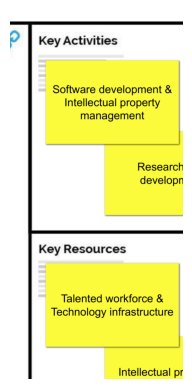

In [47]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = "/kaggle/input/datasets/fatmaadorgham/test-integ/page_0001_1.png"

img = Image.open(img_path)

# crop VALUE PROPOSITION block (adjust values)
crop = img.crop((1200, 300, 1900, 1800))

plt.imshow(crop)
plt.axis("off")

In [48]:
import numpy as np

text = easyocr_image(np.array(crop))
print(text)

0 Key Activities
Software development & Intellectual property management
Research developn
Key Resources
Talented workforce & Technology infrastructure
Intellectual pr


In [49]:
results_df = classify_ocr_text(
    text,
    tokenizer=tokenizer_cls,
    model=classifier_model,
    device=DEVICE
)

print(results_df)

                                               chunk predicted_block  \
0  0 Key Activities Software development & Intell...   key_resources   

   confidence  
0    0.394489  


In [50]:
idx = 5

bmc_json = ocr_pipeline_results[idx]["bmc_json"]

generated_bmc = generate_bmc_with_llm(bmc_json)

print(generated_bmc)

system
You are a helpful business model expert.
user

You are a Business Model Canvas expert.

Using the extracted BMC information below, generate a complete Business Model Canvas.

Input:
{
  "channels": [
    "Advertising and stock sales"
  ],
  "customer_segments": [
    "Adobe's community: Creative professionals and marketing professionals.",
    "Educators and students:"
  ],
  "value_proposition": [
    "Adobe empowers creativity and digital transformation among creative professionals.",
    "Adobe helps educators improve students' digital skills_",
    "Adobe helps enterprises digitize business processes Customer service_"
  ],
  "customer_relationships": [
    "Adobe helps students develop digital skills."
  ],
  "revenue_streams": [
    "Cloud infrastructure maintenance fee.",
    "Subscription."
  ],
  "key_resources": [
    "Talented workforce and technology infrastructure_ Intellectual property and brand reputation."
  ],
  "key_activities": [
    "Clean; non",
    "Softwar